<center><h1>Chavarkar_Rudrani_HW2</h1></center>
<br>
<br>

Name: Rudrani Chavarkar<br>
Github Username: rudranichav<br>
USC ID: 3158-2107-65

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Get the Cycle Power Plant Data Set

In [151]:
df = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx')

df.columns = ['T','V','AP','RH','EP']
df

,T,V,AP,RH,EP
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


### (b) Exploring the data

#### i. rows and columns

In [152]:
print("Rows, Columns:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:")
display(df.head())

Rows, Columns: (9568, 5)
Columns: ['T', 'V', 'AP', 'RH', 'EP']

First 5 rows:


,T,V,AP,RH,EP
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


This dataset contains 9,568 hourly observations from a Combined Cycle Power Plant (2006–2011), operating at full load, with ambient features Temperature (T), Exhaust Vacuum (V), Ambient Pressure (AP), and Relative Humidity (RH).

These variables are used to predict the net hourly electrical energy output (EP), where T, AP, and RH primarily affect gas turbine performance, and V influences the steam turbine.


#### ii. pairwise scatterplots of all the varianbles

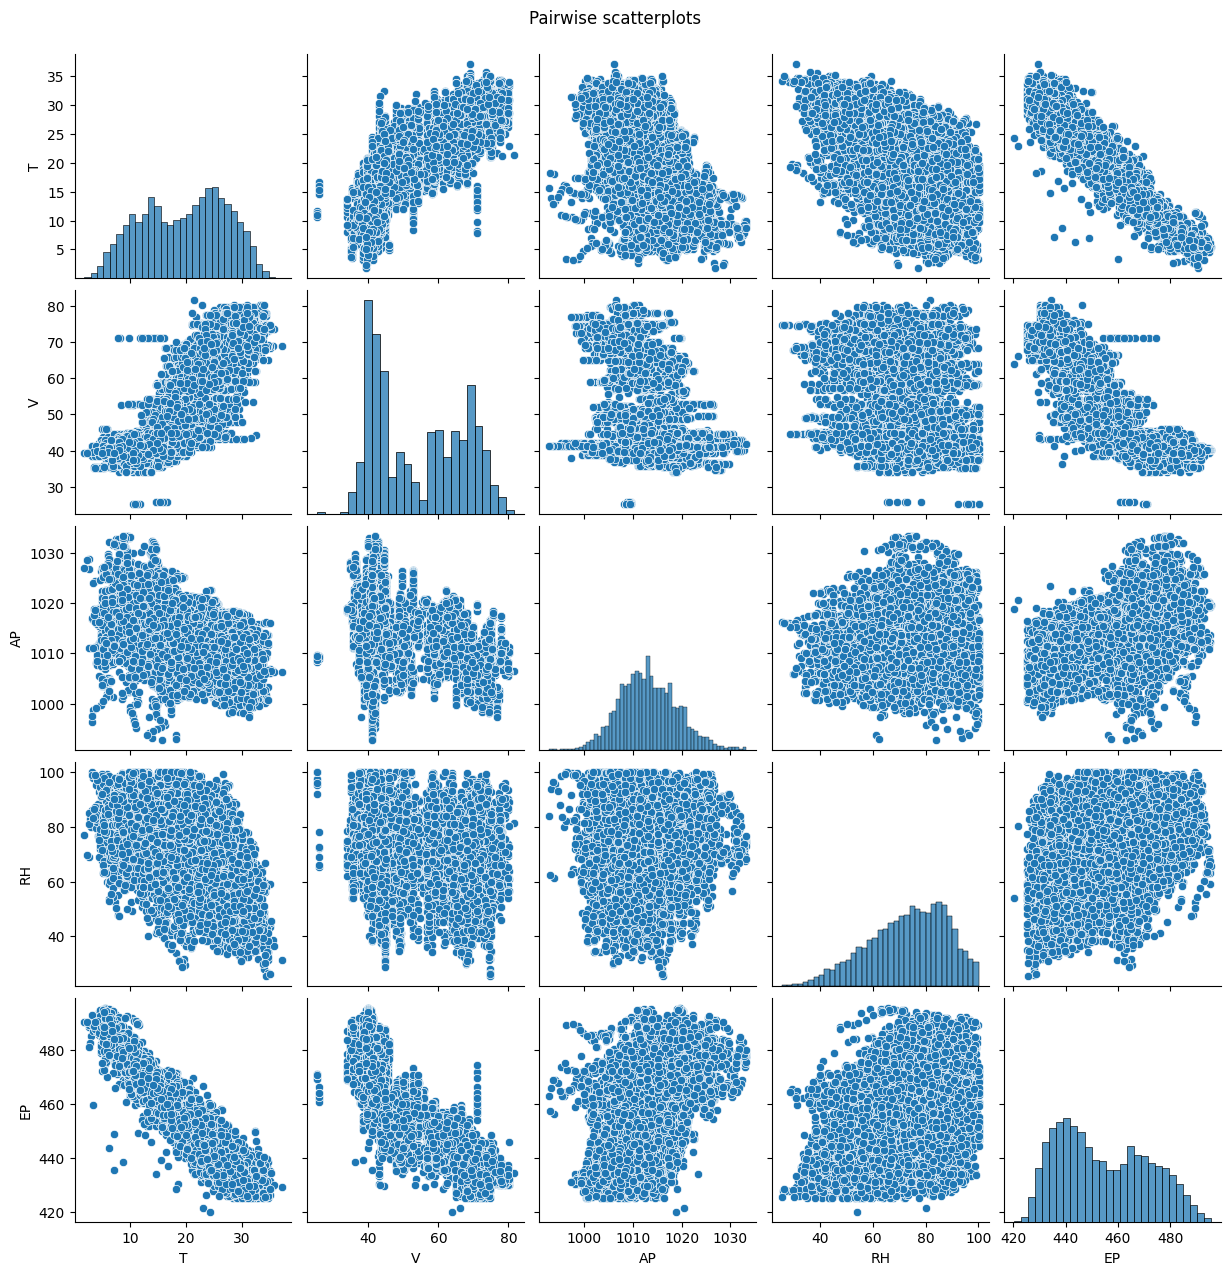

In [153]:
sns.pairplot(df, vars=df.columns, ) 
plt.suptitle("Pairwise scatterplots", y=1.02)
plt.show()

### Relationship Between Features and Energy Output (PE)

- **T vs EP:** Strong negative correlation. As temperature increases (~20 units), energy output decreases significantly (~60 units), indicating reduced gas turbine efficiency at higher temperatures.

- **V vs EP:** Negative correlation. Energy output decreases with higher exhaust vacuum, though the decline is slower at lower vacuum levels (40–50 units). Some potential outliers are observed.

- **AP vs PE:** Weak positive correlation. Energy output slightly increases with pressure, but the relationship is weak and widely scattered.

- **RH vs PE:** Extremely weak positive correlation, indicating minimal impact on energy output.

### Feature Relationships

- **AT and V:** Strong positive correlation.  
- **AP:** Almost no correlation with AT and V.  
- **RH:** Weak negative correlation with AT and little to no correlation with AP and V.

### Summary

AT and V are the strongest predictors of PE, while AP and RH have minimal influence. Potential outliers mainly appear in pressure-related plots.


#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [154]:
summary = df.agg(['mean', 'median', 'min', 'max', 'std']).T
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1
summary['Q1 (25%)'] = q1
summary['Q3 (75%)'] = q3
summary['IQR'] = iqr
summary['range'] = summary['max'] - summary['min']
summary = summary[['mean','median','min','max','range','Q1 (25%)','Q3 (75%)','IQR','std']]
display(summary)

,mean,median,min,max,range,Q1 (25%),Q3 (75%),IQR,std
T,19.651231,20.345,1.81,37.11,35.30,13.5100,25.72,12.2100,7.452473
V,54.305804,52.080,25.36,81.56,56.20,41.7400,66.54,24.8000,12.707893
AP,1013.259078,1012.940,992.89,1033.30,40.41,1009.1000,1017.26,8.1600,5.938784
RH,73.308978,74.975,25.56,100.16,74.60,63.3275,84.83,21.5025,14.600269
EP,454.365009,451.550,420.26,495.76,75.50,439.7500,468.43,28.6800,17.066995


### (c) Simple Linear Regression

In [155]:
predictors = df.columns.drop("EP")

simple_results = {}
for p in predictors:
    formula = f"EP ~ {p}"
    model = smf.ols(formula, data=df).fit()
    simple_results[p] = model
    print("="*60)
    print("Simple regression: EP with ", p)
    print(model.summary().tables[1])
    print("R-squared:", model.rsquared)
    print()

Simple regression: EP with  T
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.000     496.727     497.341
T             -2.1713      0.007   -291.715      0.000      -2.186      -2.157
R-squared: 0.8989475964148236

Simple regression: EP with  V
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    517.8015      0.378   1370.218      0.000     517.061     518.542
V             -1.1681      0.007   -172.402      0.000      -1.181      -1.155
R-squared: 0.7565177870683979

Simple regression: EP with  AP
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1055.2610     25.459    -41.449      0.000   

### Simple Linear Regression Results (Least Squares Method)

### EP and T

a) The coefficient is **-2.17**, indicating a strong negative correlation, showing that higher GT temperature reduces EP.  

b) The **R² value is 0.899**, meaning a large proportion of the variability in EP is explained by T.  

c) The **p-value < 0.05**, indicating that T is statistically significant.  

---

### EP and V

a) The coefficient is **-1.1681**, indicating a negative correlation, meaning higher exhaust vacuum in the ST reduces EP.  

b) The **R² value is 0.757**, showing that V explains a substantial portion of the variability in EP.  

c) The **p-value < 0.05**, indicating that V is statistically significant.  

---

### EP and AP

a) The coefficient is **1.4899**, indicating a positive correlation, meaning that as GT pressure increases, EP increases.  

b) The **R² value is 0.269**, suggesting that AP is a weak predictor and does not strongly explain EP variability.  

c) The **p-value < 0.05**, indicating that AP is statistically significant.  

---

### EP and RH

a) The coefficient is **0.4557**, indicating a weak positive correlation, meaning increases in RH have minimal effect on EP.  

b) The **R² value is 0.152**, showing that RH is a very weak predictor of EP.  

c) The **p-value < 0.05**, indicating that RH is statistically significant.  

---

### Overall Interpretation

- T and V have very large t-values, indicating a strong impact on EP.  
- AP and RH are statistically significant but have smaller t-values, suggesting weaker influence and possible overlap with other predictors.  
- For all predictors, the null hypothesis (**β = 0**) is rejected since **p < 0.05**, confirming statistically significant relationships with EP.


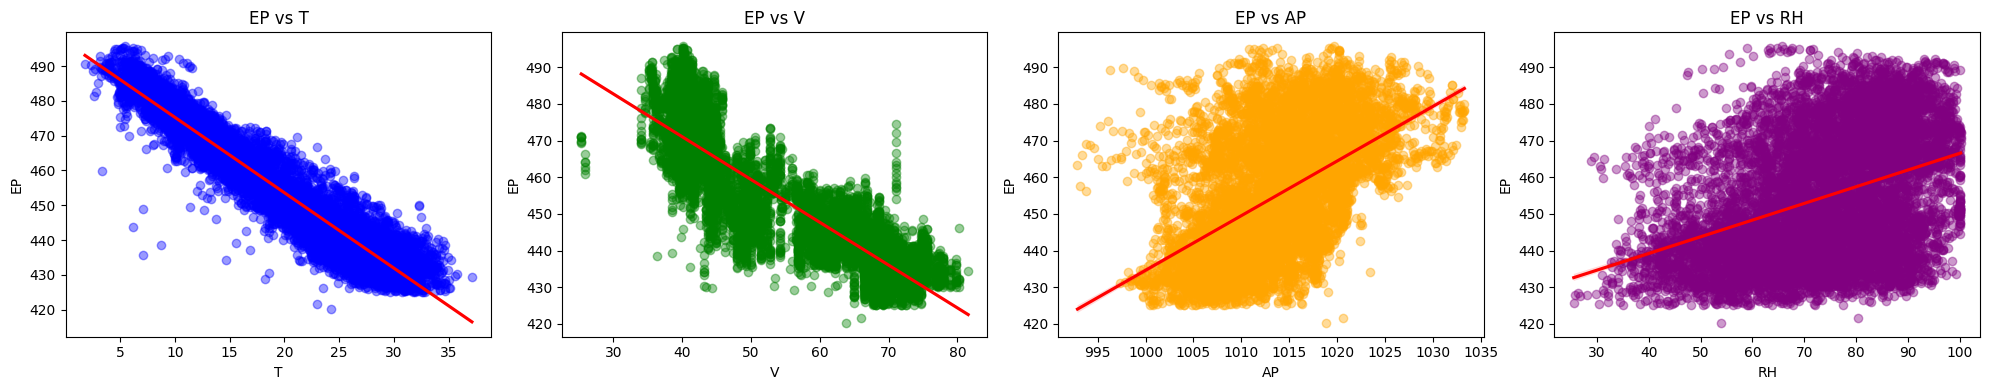

In [156]:
colors = ['blue', 'green', 'orange', 'purple']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, col, color in zip(axes, predictors, colors):
    sns.regplot(
        x=col,
        y='EP',
        data=df,
        scatter_kws={'color': color, 'alpha': 0.4},
        line_kws={'color': 'red'},
        ax=ax
    )
    ax.set_title(f"EP vs {col}")

plt.tight_layout()
plt.show()

### Regression Line Fit and Outlier Analysis

- **T and V:** Both show a clear and strong negative linear trend with EP. The regression line fits the data well.

- **AP and RH:** The regression lines show weak positive trends and are poorly fitted, with data widely scattered around the line.

### Outlier Observations

- **AP and RH:** Due to high data dispersion, identifying clear outliers is difficult.

- **T:** Data points follow a tight negative trend, with only a few minor deviations that do not significantly affect the model.

- **V:** Some data points at specific V values deviate noticeably from the regression line for the same V level. These points may be considered potential outliers and could be removed after further verification.


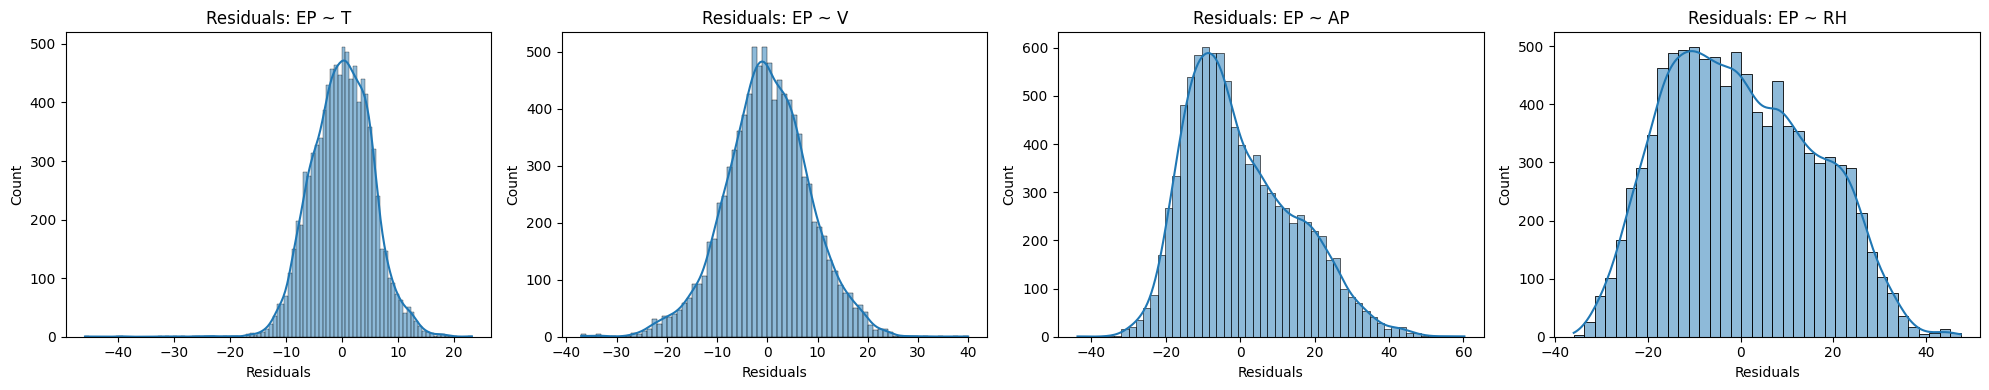

In [157]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, p in zip(axes, simple_results):
    resid = simple_results[p].resid
    sns.histplot(resid, kde=True, ax=ax)
    ax.set_title(f"Residuals: EP ~ {p}")
    ax.set_xlabel("Residuals")

plt.tight_layout()
plt.show()

### (d) Multiple Regression

In [158]:
full_model = smf.ols("EP ~ T + AP + RH + V", data=df).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:49:12   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

### Multiple Linear Regression Model Interpretation

- All four predictors have **p-values < 0.05**, indicating they are statistically significant.  
  Therefore, the **null hypothesis (β = 0)** is rejected for all predictors.

- The strongest predictor of EP is **T**, while the weakest is **AP**.

- **T, V, and RH** show a negative correlation with EP.  
- **AP** shows a very weak positive correlation with EP.

- The model has an **R² value of 0.929**, indicating an excellent fit and showing that 92.9% of the variability in EP is explained by the combined effect of all four predictors.


### (e) 1c Compare to 1d

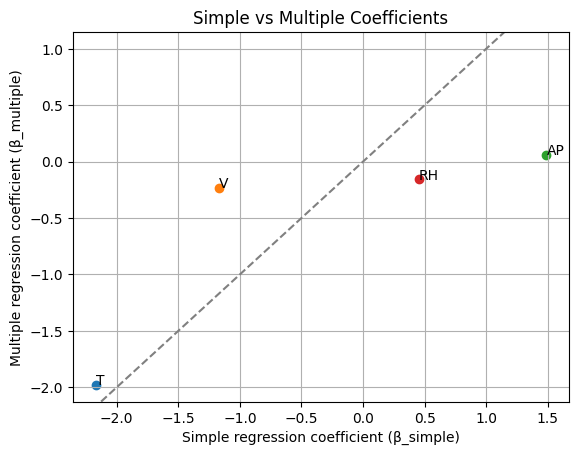

In [159]:
simple_coefs = {p: simple_results[p].params[p] for p in predictors}
multiple_coefs = full_model.params.to_dict()

x = [simple_coefs[p] for p in predictors]
y = [multiple_coefs.get(p, np.nan) for p in predictors]

plt.figure()
for i, p in enumerate(predictors):
    plt.scatter(x[i], y[i])
    plt.text(x[i], y[i], p)
plt.axline((0,0),(1,1), linestyle='--', color='gray')
plt.xlabel("Simple regression coefficient (β_simple)")
plt.ylabel("Multiple regression coefficient (β_multiple)")
plt.title("Simple vs Multiple Coefficients")
plt.grid(True)
plt.show()

### Comparison: Simple vs Multiple Regression

- **T (AT):**  
  The coefficient slightly decreased from **-2.1713 (simple)** to **-1.9775 (multiple)**, but it still shows a strong negative correlation with EP and remains the strongest predictor.

- **V:**  
  The coefficient sharply declined from **-1.1681** to **-0.2339**, suggesting that much of its apparent impact on EP in simple regression was due to its strong positive correlation with T.

- **AP:**  
  The coefficient dropped significantly from **1.4899** to **0.0621**, indicating it has almost no direct impact on EP when other predictors are included.  
  This suggests its earlier effect was likely due to correlation with other predictors rather than a true independent relationship with EP.  
  Its small t-statistic in simple regression supports the idea of weak beta estimation.

- **RH:**  
  The coefficient changed from a positive **0.4557 (simple)** to a negative **-0.1581 (multiple)**, indicating that after accounting for other predictors, RH shows a true negative relationship with EP.

---

### Model Fit and Significance

- The **R² value of the multiple regression** is higher than the R² of any individual simple regression model, confirming that the combined predictors provide the best fit.

- All predictors remain **statistically significant (p < 0.05)**.  
  However, their relative impact differs based on t-values, with **T and RH** showing the strongest effects due to larger t-statistics.


### (f) Nonlinear Association

In [160]:
poly_results = {}
for p in predictors:
    df[f'{p}_2'] = df[p]**2
    df[f'{p}_3'] = df[p]**3
    formula = f"EP ~ {p} + {p}_2 + {p}_3"
    model = smf.ols(formula, data=df).fit()
    poly_results[p] = model
    print("="*60)
    print("Polynomial regression: EP ~", p, "+", p+"^2 +", p+"^3")
    print(model.summary().tables[1])
    print()

Polynomial regression: EP ~ T + T^2 + T^3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      0.000     491.409     494.047
T             -0.6103      0.124     -4.941      0.000      -0.852      -0.368
T_2           -0.1251      0.007    -18.199      0.000      -0.139      -0.112
T_3            0.0027      0.000     22.594      0.000       0.002       0.003

Polynomial regression: EP ~ V + V^2 + V^3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    554.1468      9.151     60.557      0.000     536.209     572.084
V             -2.1444      0.509     -4.214      0.000      -3.142      -1.147
V_2           -0.0027      0.009     -0.294      0.768      -0.021       0.015
V_3            0.0001   5.45e-05      2.465   

On observing the P-values for the quadratic (X^2) and cubic (X^3) parameter, it is easily observable that the p-values of these parameters for AT, AP and RH are all less than 0.05, meaning that these parameters are significant and imply that there is a non-linear association between these three predictors and PE for a model of this form.
For the V predictor, the quadratic term is not significant (0.768) whereas the cubic term is significant (0.014) , which means that the overall model has a non-linear relationship which is mainly captured at the cubic level for the model of this form.

### (g) Interactions of Predictors

In [161]:
interaction_model = smf.ols("EP ~ (T + AP + RH + V)**2", data=df).fit()
print(interaction_model.summary())

coefs = interaction_model.params
pvals = interaction_model.pvalues
sig_interactions = [(name, pvals[name]) for name in pvals.index if ":" in name and pvals[name] < 0.05]
print("\nSignificant interaction terms (p < 0.05):")
print(sig_interactions)

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        20:49:12   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

### Interaction Effects Between Predictors and EP

There is evidence that certain predictors interact significantly in affecting EP.

- The p-value of **T (AT)** suggests that it does not act entirely independently in influencing EP.  
  Its interactions with **V** and **RH** are statistically significant, indicating that its effect on EP depends on these predictors.

- The p-values of **V, AP, and RH** suggest that they largely act independently in predicting EP.

### Statistically Significant Interaction Terms (p < 0.05)

- **T : V**  
- **T : RH**  
- **AP : V**  
- **AP : RH**

These results imply that the effects of **T and AP** on EP vary depending on the levels of **V and RH**.

### Non-Significant Interactions

- **AP : T**  
- **RH : V**

These pairs show no statistical evidence of interaction, indicating their combined effects do not significantly influence EP beyond their individual contributions.


### (h) Improvement

In [162]:
train, test = train_test_split(df, test_size=0.3, random_state=50)

In [163]:
# -----------------------------
# Model A: Multiple Linear Regression
# -----------------------------

model_A = smf.ols("EP ~ T + AP + RH + V", data=train).fit()

pred_A_train = model_A.predict(train)
pred_A_test = model_A.predict(test)

mse_A_train = mean_squared_error(train['EP'], pred_A_train)
mse_A_test = mean_squared_error(test['EP'], pred_A_test)

print("======== Model A: Multiple Linear Regression ========")
print("Train MSE:", mse_A_train)
print("Test MSE:", mse_A_test)
print("\nModel A Coefficients:")
print(model_A.summary().tables[1])
print("\n\n")


======== Model A: Multiple Linear Regression ========
Train MSE: 20.88349503806925
Test MSE: 20.504273828545866

Model A Coefficients:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    453.4075     11.538     39.297      0.000     430.789     476.025
T             -1.9728      0.018   -108.132      0.000      -2.009      -1.937
AP             0.0634      0.011      5.661      0.000       0.041       0.085
RH            -0.1572      0.005    -31.628      0.000      -0.167      -0.147
V             -0.2392      0.009    -27.368      0.000      -0.256      -0.222





In [164]:
formula_B = "EP ~ (T + AP + RH + V)**2 + T_2 + AP_2 + RH_2 + V_2"
model = smf.ols(formula_B, data=train).fit()

def backward_by_pvals(model, data, threshold=0.05, max_iter=20):
    # get current term names (excluding intercept)
    terms = model.model.exog_names.copy()
    if 'Intercept' in terms:
        terms.remove('Intercept')

    it = 0
    while it < max_iter:
        pvals = model.pvalues.drop('Intercept', errors='ignore')
        pvals = pvals[[t for t in pvals.index if t in terms]]

        if pvals.empty:
            break

        worst_term = pvals.idxmax()
        worst_p = pvals.max()

        if worst_p <= threshold:
            break

        terms.remove(worst_term)

        rhs = " + ".join(terms)
        formula = "EP ~ " + rhs
        model = smf.ols(formula, data=data).fit()

        it += 1

    return model

# Run backward selection
model_B_reduced = backward_by_pvals(model, train, threshold=0.05, max_iter=15)

# Predictions
pred_B_train = model_B_reduced.predict(train)
pred_B_test = model_B_reduced.predict(test)

# MSE calculations
mse_B_train = mean_squared_error(train['EP'], pred_B_train)
mse_B_test = mean_squared_error(test['EP'], pred_B_test)

print("======== Reduced Model B Results ========")
print("Train MSE:", mse_B_train)
print("Test MSE:", mse_B_test)

print("\nFinal Coefficients:")
print(model_B_reduced.summary().tables[1])


======== Reduced Model B Results ========
Train MSE: 18.12024942201809
Test MSE: 18.115105961353038

Final Coefficients:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8227.9648   1217.717     -6.757      0.000   -1.06e+04   -5840.852
T             -2.5379      0.111    -22.794      0.000      -2.756      -2.320
AP            17.0265      2.372      7.178      0.000      12.376      21.677
RH             4.5314      0.814      5.566      0.000       2.935       6.127
V             -4.5274      1.074     -4.217      0.000      -6.632      -2.423
T:RH          -0.0061      0.001     -6.676      0.000      -0.008      -0.004
T:V            0.0103      0.002      6.701      0.000       0.007       0.013
AP:RH         -0.0042      0.001     -5.361      0.000      -0.006      -0.003
AP:V           0.0040      0.001      3.776      0.000       0.002       0.006
T_2       

### (i) KNN

In [165]:
X = df[['T','AP','RH','V']].values
y = df['EP'].values

# Split once (same split as before for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

# Raw features
train_mse_raw = []
test_mse_raw = []
# Normalized features
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
train_mse_scaled = []
test_mse_scaled = []

ks = range(1, 101)
for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k)
    # raw
    knn.fit(X_train, y_train)
    ytr_pred = knn.predict(X_train)
    yte_pred = knn.predict(X_test)
    train_mse_raw.append(mean_squared_error(y_train, ytr_pred))
    test_mse_raw.append(mean_squared_error(y_test, yte_pred))
    # scaled
    knn.fit(X_train_scaled, y_train)
    ytr_pred_s = knn.predict(X_train_scaled)
    yte_pred_s = knn.predict(X_test_scaled)
    train_mse_scaled.append(mean_squared_error(y_train, ytr_pred_s))
    test_mse_scaled.append(mean_squared_error(y_test, yte_pred_s))

In [166]:
# Find best k for scaled and raw
best_k_raw = ks[np.argmin(test_mse_raw)]
best_k_scaled = ks[np.argmin(test_mse_scaled)]
print("Best k (raw) by test MSE:", best_k_raw, "MSE:", min(test_mse_raw))
print("Best k (scaled) by test MSE:", best_k_scaled, "MSE:", min(test_mse_scaled))

Best k (raw) by test MSE: 5 MSE: 16.00153278160919
Best k (scaled) by test MSE: 7 MSE: 15.077676351125614


Text(0.5, 1.0, 'KNN (scaled) MSE vs 1/k')

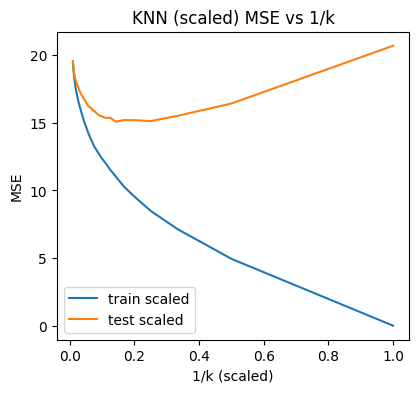

In [167]:
# Plot train/test MSE vs 1/k
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot([1/k for k in ks], train_mse_scaled, label='train scaled')
plt.plot([1/k for k in ks], test_mse_scaled, label='test scaled')
plt.xlabel("1/k (scaled)")
plt.ylabel("MSE")
plt.legend()
plt.title("KNN (scaled) MSE vs 1/k")

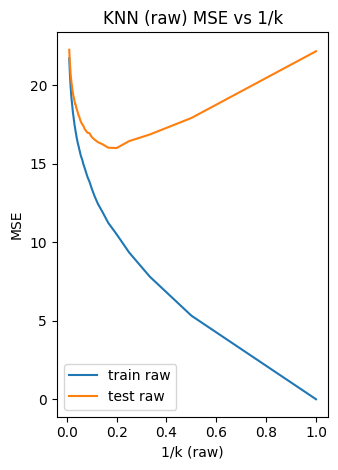

In [168]:
plt.subplot(1,2,2)
plt.plot([1/k for k in ks], train_mse_raw, label='train raw')
plt.plot([1/k for k in ks], test_mse_raw, label='test raw')
plt.xlabel("1/k (raw)")
plt.ylabel("MSE")
plt.legend()
plt.title("KNN (raw) MSE vs 1/k")
plt.tight_layout()
plt.show()

### (j ) Compare KNN and Linear

In [169]:
best_knn_mse = min(test_mse_scaled)
print("Best KNN (scaled) test MSE:", best_knn_mse)
print("Model A test MSE:", mse_A_test)
print("Model B (reduced) test MSE:", mse_B_test)

# Short comment (printed)
if best_knn_mse < mse_B_test:
    print("KNN (scaled) performed better on test set than the reduced complex linear model.")
else:
    print("Linear model (reduced or simple) performed as well or better than KNN on this test set.")

Best KNN (scaled) test MSE: 15.077676351125614
Model A test MSE: 20.504273828545866
Model B (reduced) test MSE: 18.115105961353038
KNN (scaled) performed better on test set than the reduced complex linear model.


The linear regression model, including quadratic and interaction terms, achieved an **adjusted R² of 0.938**, explaining about 94% of the variance in EP. It provides strong interpretability of predictor effects. However, its **test MSE was higher** than that of KNN.

KNN regression performed best with **normalized features at k = 7**, producing a **test MSE of 15.08**, compared to **16.00 with raw features**. This was the lowest test error among all models, indicating that KNN captured complex local nonlinear patterns more effectively. Normalization improved performance, as expected, since KNN is distance-based and sensitive to feature scale.

Conclusion

- **Regression:** Better interpretability and insight into predictor relationships.  
- **KNN:** Better predictive accuracy (lower test MSE).  

Therefore, if minimizing prediction error is the main objective, **KNN is preferred**, while regression remains valuable for understanding underlying relationships.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

When the sample size is very large and the number of predictors is small, a flexible model will generally perform better. Because there is a lot of data available, the model can learn complex patterns without overfitting easily. The large amount of data helps reduce variance, so even if the model is flexible (like using higher-order polynomial terms), it can still generalize well to new data.

On the other hand, an inflexible model (like simple linear regression) may not fully capture complex relationships in the data. This can lead to high bias and underfitting. So in this case, a flexible model is preferred.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

When the number of predictors is very large but the number of observations is small, a flexible model is more likely to overfit. Since there are many predictors and very little data, the model may try to fit the noise instead of the true pattern. This results in low training error but high test error due to high variance.

An inflexible model is better in this case because it makes stronger assumptions and does not try to fit every small fluctuation in the data. Even though it may have higher bias, it will usually have lower variance and better generalization on test data.

### (c) The relationship between the predictors and response is highly non-linear.

If the true relationship between predictors and the response is highly non-linear, a flexible model will perform better. Flexible models can capture complex patterns and curved relationships in the data, which reduces bias.

An inflexible model assumes a simple form (like a straight line), so it will not be able to capture the non-linear structure. This leads to underfitting, high bias, and higher training and test errors.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

If the error variance is very high, it means the data contains a lot of noise. In this case, a flexible model may try to fit this noise as if it were a real pattern. This increases variance and leads to overfitting, which hurts test performance.

An inflexible model is less likely to chase the noise because it cannot fit very complex patterns. Even though it may not capture every detail, it can generalize better in noisy situations due to lower variance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

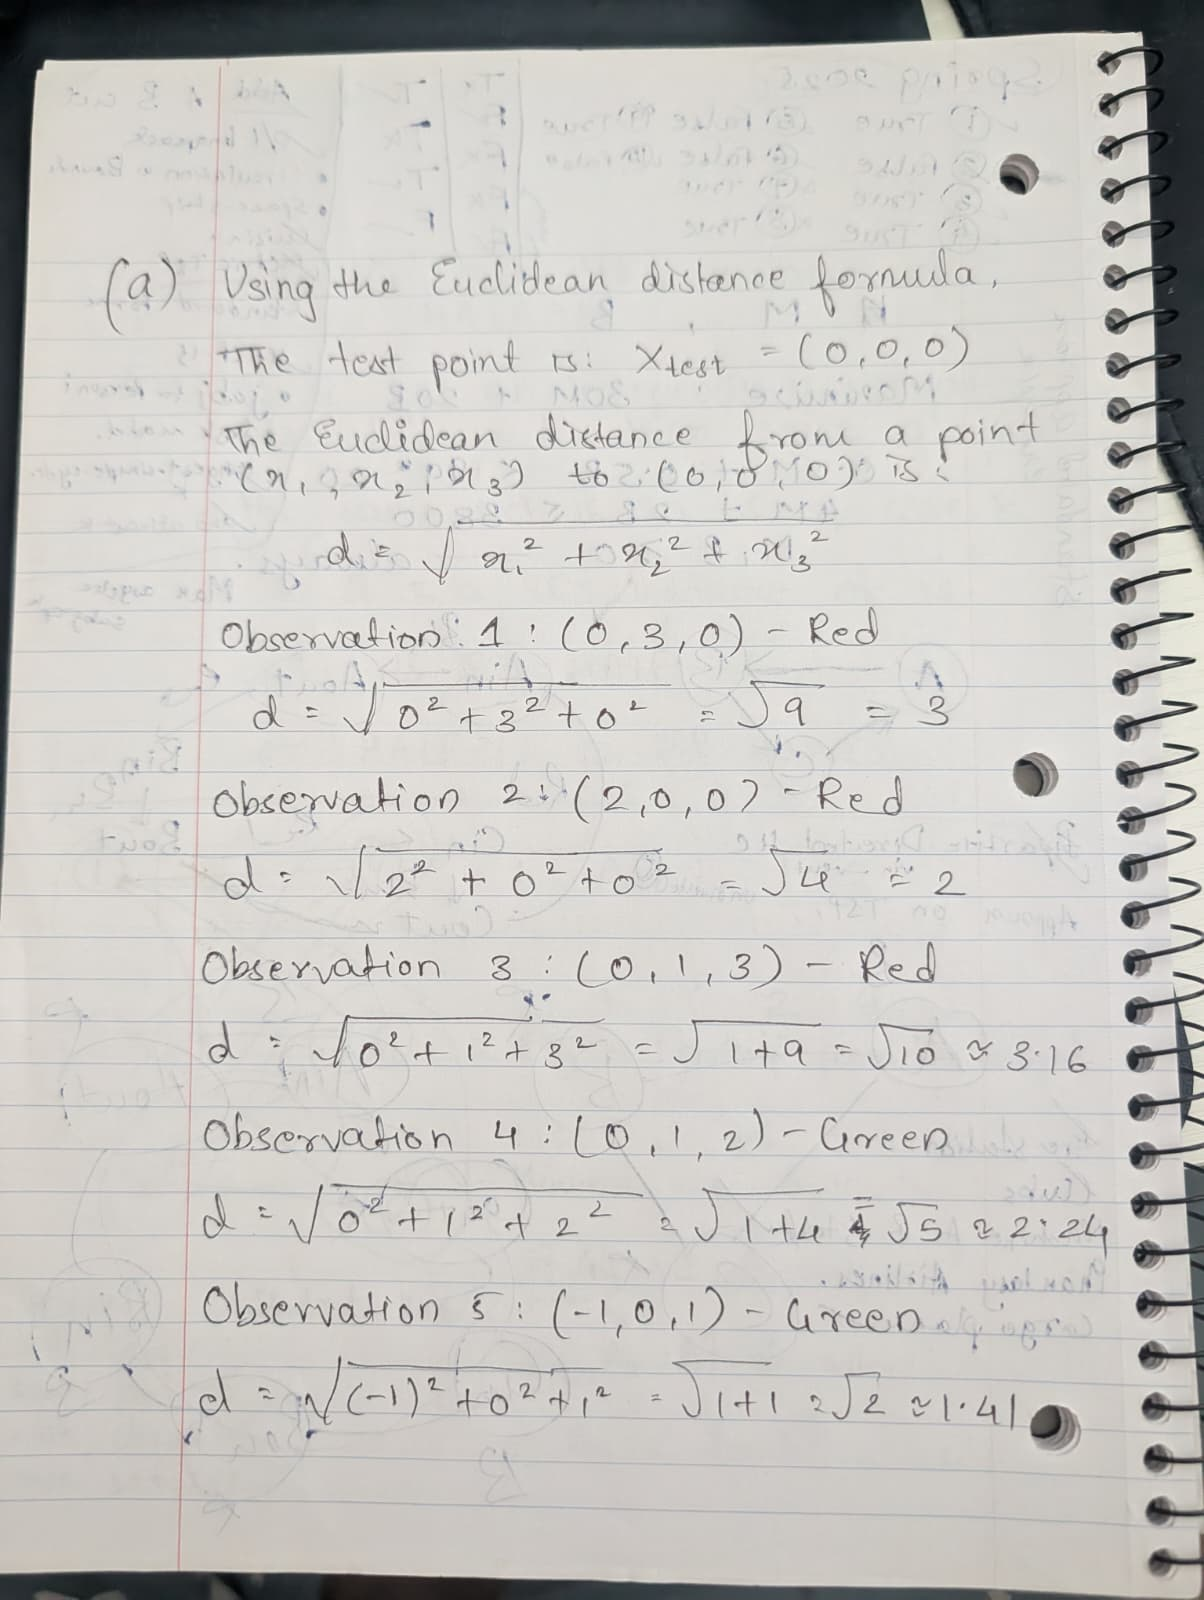

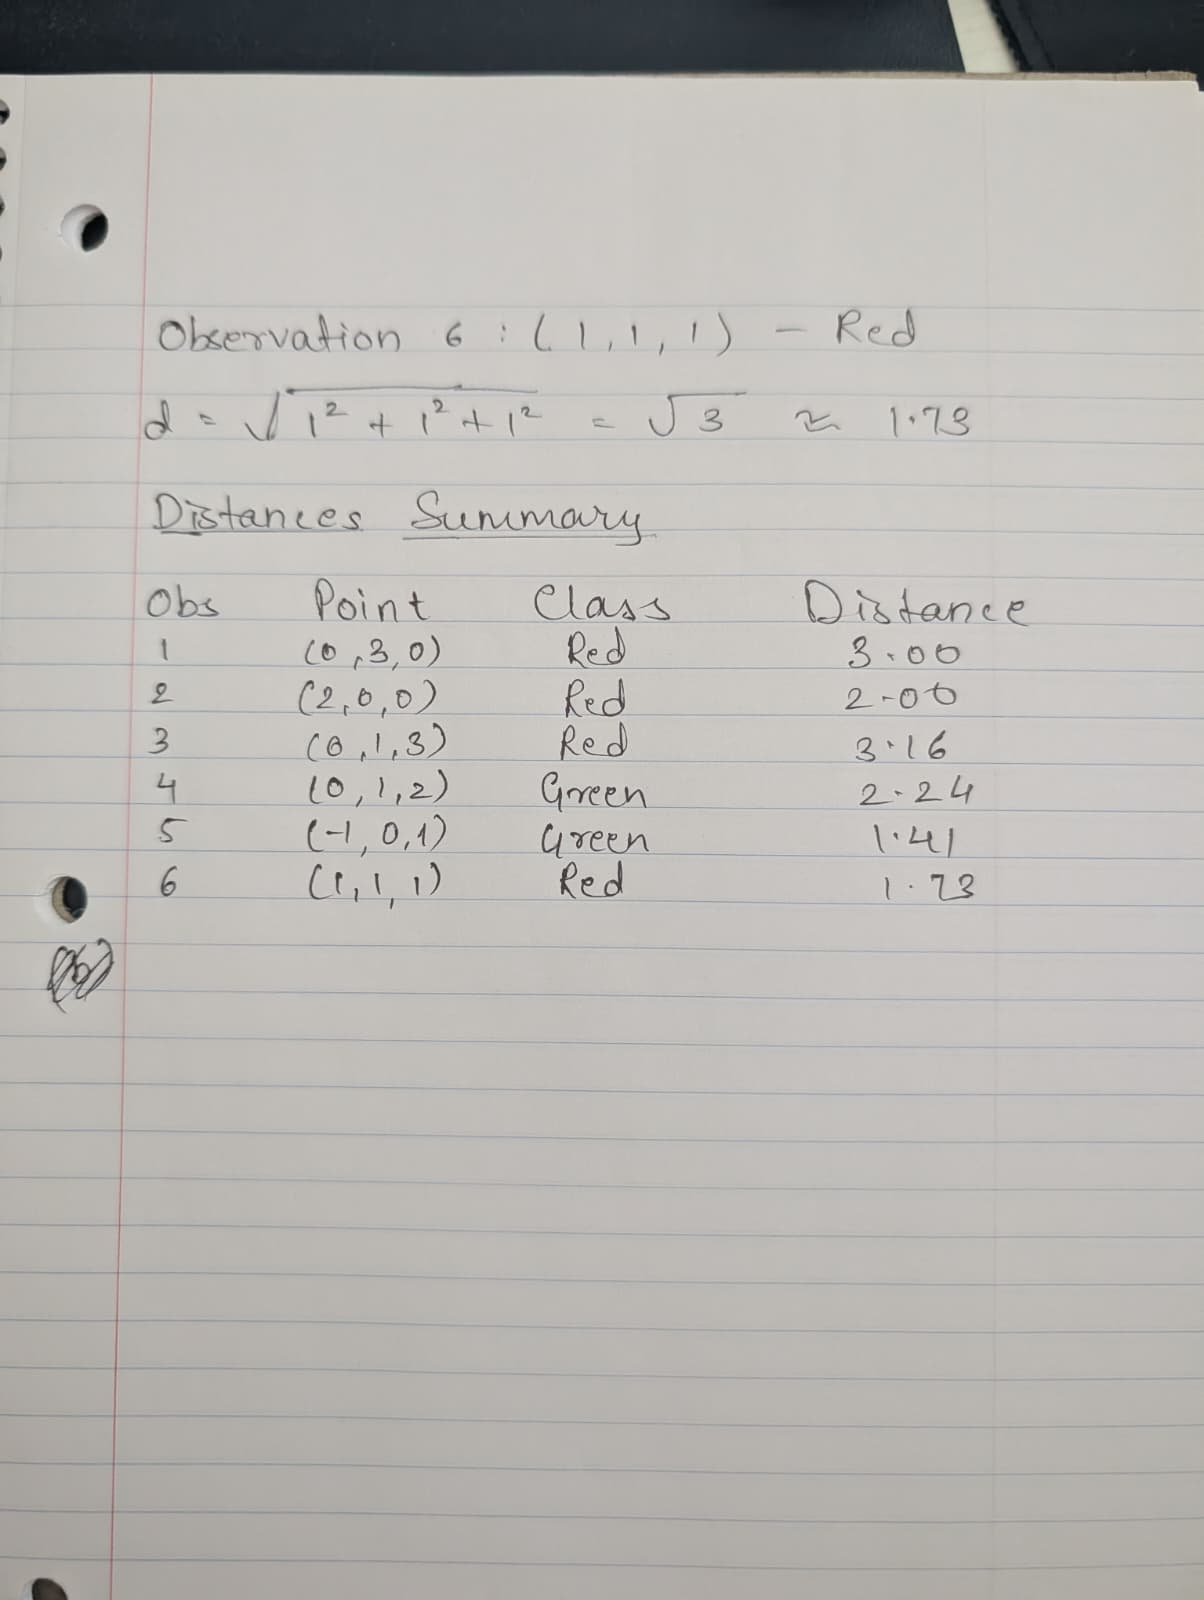

### (b) What is our prediction with K = 1? Why?

The nearest neighbor is the smallest distance: 1.41
This corresponds to: Observation 5 → Green
Prediction with K = 1: Green
Because the single closest point is Green.

### (c) What is our prediction with K = 3? Why?

Now take the 3 smallest distances:
1.41 → Green (Obs 5)
1.73 → Red (Obs 6)
2.00 → Red (Obs 2)
Votes:
Red: 2
Green: 1
Majority = Red
Prediction with K = 3: Red
	​


### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

If the Bayes decision boundary is highly non-linear, we would expect a small K to perform better.

Reason:

Small K → more flexible → captures complex patterns.

Large K → smoother boundary → may miss non-linear structure.

So for highly non-linear boundaries, small K is preferred.